In [29]:
import pandas as pd
import os

DATA_DIR = "data_raw_fbref"
CATEGORIAS = ["standard", "shooting", "passing", "defense", "possession"]

for nombre in CATEGORIAS:
    ruta = os.path.join(DATA_DIR, f"{nombre}.csv")
    if not os.path.exists(ruta):
        print(f"[{nombre}] no existe el archivo\n")
        continue

    df = pd.read_csv(ruta)
    print(f"=== {nombre} ===")
    print(f"Filas: {len(df)}  |  Columnas: {len(df.columns)}")
    print("Primeras columnas:", list(df.columns[:10]))
    print()

=== standard ===
Filas: 2839  |  Columnas: 26
Primeras columnas: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'Playing Time_MP', 'Playing Time_Starts']

=== shooting ===
Filas: 2839  |  Columnas: 20
Primeras columnas: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Standard_Gls']

=== passing ===
Filas: 2839  |  Columnas: 30
Primeras columnas: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Total_Cmp']

=== defense ===
Filas: 2839  |  Columnas: 26
Primeras columnas: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Tackles_Tkl']

=== possession ===
Filas: 2839  |  Columnas: 30
Primeras columnas: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Touches_Touches']



In [30]:
df = pd.read_csv("data_raw_fbref/standard.csv")
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,...,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Matches
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,0,0,3,0,0.15,0.18,0.33,0.15,0.33,Matches
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
2,3,Zach Abbott,eng ENG,DF,Nottingham,eng Premier League,19.0,2006.0,3,2,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,0,0.26,0.00,0.26,0.26,0.26,Matches
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches


In [31]:
import pandas as pd
import os

DATA_DIR = "data_raw_fbref"
CATEGORIAS = ["standard", "shooting", "passing", "defense", "possession"]

# columnas que se repiten igual en todas las tablas (info del jugador)
COLUMNAS_CLAVE = ["Player", "Nation", "Pos", "Squad", "Comp", "Age", "Born"]


def main():
    tablas = {}
    for nombre in CATEGORIAS:
        ruta = os.path.join(DATA_DIR, f"{nombre}.csv")
        tablas[nombre] = pd.read_csv(ruta)
        print(f"[{nombre}] cargada: {len(tablas[nombre])} filas")

    # partimos de la tabla "standard" como base
    df_final = tablas["standard"].copy()

    for nombre in CATEGORIAS[1:]:
        tabla = tablas[nombre]

        # quitamos columnas duplicadas de info de jugador (ya están en df_final),
        # excepto las claves usadas para unir
        columnas_a_quitar = [c for c in COLUMNAS_CLAVE if c in tabla.columns
                              and c not in ["Player", "Squad", "Comp"]]
        tabla = tabla.drop(columns=columnas_a_quitar, errors="ignore")

        # también quitamos "Rk" y "90s" repetidos (no aportan al unir)
        tabla = tabla.drop(columns=["Rk", "90s"], errors="ignore")

        df_final = df_final.merge(
            tabla,
            on=["Player", "Squad", "Comp"],
            how="left",
            suffixes=("", f"_{nombre}")
        )
        print(f"Unido con [{nombre}] -> {len(df_final)} filas, "
              f"{len(df_final.columns)} columnas")

    out_path = os.path.join(DATA_DIR, "dataset_unificado.csv")
    df_final.to_csv(out_path, index=False)
    print(f"\n¡Listo! Dataset unificado guardado en {out_path}")
    print(f"Total: {len(df_final)} filas, {len(df_final.columns)} columnas")


if __name__ == "__main__":
    main()

[standard] cargada: 2839 filas
[shooting] cargada: 2839 filas
[passing] cargada: 2839 filas
[defense] cargada: 2839 filas
[possession] cargada: 2839 filas
Unido con [shooting] -> 2839 filas, 37 columnas
Unido con [passing] -> 2839 filas, 58 columnas
Unido con [defense] -> 2839 filas, 75 columnas
Unido con [possession] -> 2839 filas, 96 columnas

¡Listo! Dataset unificado guardado en data_raw_fbref\dataset_unificado.csv
Total: 2839 filas, 96 columnas


In [32]:
import pandas as pd

DATA_DIR = "data_raw_fbref"
df = pd.read_csv(f"{DATA_DIR}/dataset_unificado.csv")
print(f"Dataset original: {len(df)} filas")

# buscamos la columna de minutos jugados
columnas_min = [c for c in df.columns if "Min" in c]
print("Columnas candidatas:", columnas_min)

Dataset original: 2839 filas
Columnas candidatas: ['Playing Time_Min', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK']


In [33]:
import pandas as pd

DATA_DIR = "data_raw_fbref"
MIN_MINUTOS = 450  # equivalente a 5 partidos completos, umbral razonable

df = pd.read_csv(f"{DATA_DIR}/dataset_unificado.csv")
print(f"Dataset original: {len(df)} filas")

# la columna de minutos viene como texto con comas de miles (ej. "1,234")
df["Playing Time_Min"] = (
    df["Playing Time_Min"].astype(str).str.replace(",", "").astype(float)
)

df_limpio = df[df["Playing Time_Min"] >= MIN_MINUTOS].copy()
df_limpio = df_limpio.reset_index(drop=True)

print(f"Dataset filtrado (>= {MIN_MINUTOS} minutos): {len(df_limpio)} filas")
print(f"Jugadores eliminados por pocos minutos: {len(df) - len(df_limpio)}")

out_path = f"{DATA_DIR}/dataset_limpio.csv"
df_limpio.to_csv(out_path, index=False)
print(f"\nGuardado en {out_path}")

Dataset original: 2839 filas
Dataset filtrado (>= 450 minutos): 1998 filas
Jugadores eliminados por pocos minutos: 841

Guardado en data_raw_fbref/dataset_limpio.csv


In [34]:
import pandas as pd

df = pd.read_csv("data_raw_fbref/dataset_limpio.csv")
print(df["Pos"].value_counts())

Pos
MF       613
DF       516
MF,FW    204
FW       200
GK       139
DF,MF    121
FW,MF    107
MF,DF     98
Name: count, dtype: int64


In [35]:
import pandas as pd

df = pd.read_csv("data_raw_fbref/dataset_limpio.csv")

# posición principal = primera parte antes de la coma
df["Pos_Principal"] = df["Pos"].str.split(",").str[0]
print(df["Pos_Principal"].value_counts())

# buscamos las columnas clave para los KPIs
print("\nColumnas de goles/xG:", [c for c in df.columns if "Gls" in c or "xG" in c])
print("\nColumnas de asistencias/xA:", [c for c in df.columns if "Ast" in c or "xA" in c])
print("\nColumnas de pases progresivos:", [c for c in df.columns if "Prog" in c])
print("\nColumnas de duelos/tackles:", [c for c in df.columns if "Tkl" in c or "Won" in c])
print("\nColumnas de intercepciones:", [c for c in df.columns if "Int" in c])

Pos_Principal
MF    915
DF    637
FW    307
GK    139
Name: count, dtype: int64

Columnas de goles/xG: ['Performance_Gls', 'Per 90 Minutes_Gls', 'Standard_Gls']

Columnas de asistencias/xA: ['Performance_Ast', 'Per 90 Minutes_Ast', 'Ast', 'A-xAG']

Columnas de pases progresivos: []

Columnas de duelos/tackles: ['Tackles_Tkl', 'Tackles_TklW', 'Challenges_Tkl', 'Challenges_Tkl%', 'Tkl+Int', 'Take-Ons_Tkld', 'Take-Ons_Tkld%']

Columnas de intercepciones: ['Int', 'Tkl+Int']


In [36]:
shooting = pd.read_csv("data_raw_fbref/shooting.csv")
print("SHOOTING:", list(shooting.columns))

passing = pd.read_csv("data_raw_fbref/passing.csv")
print("\nPASSING:", list(passing.columns))

SHOOTING: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Standard_Gls', 'Standard_Sh', 'Standard_SoT', 'Standard_SoT%', 'Standard_Sh/90', 'Standard_SoT/90', 'Standard_G/Sh', 'Standard_G/SoT', 'Standard_PK', 'Standard_PKatt', 'Matches']

PASSING: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Total_Cmp', 'Total_Att', 'Total_Cmp%', 'Total_TotDist', 'Total_PrgDist', 'Short_Cmp', 'Short_Att', 'Short_Cmp%', 'Medium_Cmp', 'Medium_Att', 'Medium_Cmp%', 'Long_Cmp', 'Long_Att', 'Long_Cmp%', 'Ast', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'Matches']


In [37]:
from understatapi import UnderstatClient
import pandas as pd
import time
import os

SEASON = "2025"  # temporada 2025-2026

LIGAS_UNDERSTAT = {
    "premier_league": "EPL",
    "la_liga": "La_Liga",
    "bundesliga": "Bundesliga",
    "serie_a": "Serie_A",
    "ligue_1": "Ligue_1"
}

DATA_DIR = "data_raw_understat"
os.makedirs(DATA_DIR, exist_ok=True)


def main():
    with UnderstatClient() as understat:
        todas_las_ligas = []

        for nombre_liga, codigo_liga in LIGAS_UNDERSTAT.items():
            print(f"[{nombre_liga}] descargando datos de Understat...")

            try:
                datos = understat.league(league=codigo_liga).get_player_data(season=SEASON)
            except Exception as e:
                print(f"  Error: {e}")
                continue

            df = pd.DataFrame(datos)
            df["liga"] = nombre_liga
            todas_las_ligas.append(df)

            out_path = os.path.join(DATA_DIR, f"{nombre_liga}_understat.csv")
            df.to_csv(out_path, index=False)
            print(f"  OK. {len(df)} jugadores guardados en {out_path}")

            time.sleep(3)

    if todas_las_ligas:
        df_final = pd.concat(todas_las_ligas, ignore_index=True)
        out_path = os.path.join(DATA_DIR, "understat_todas_las_ligas.csv")
        df_final.to_csv(out_path, index=False)
        print(f"\n¡Listo! Total: {len(df_final)} jugadores en {out_path}")


main()

[premier_league] descargando datos de Understat...
  OK. 537 jugadores guardados en data_raw_understat\premier_league_understat.csv
[la_liga] descargando datos de Understat...
  OK. 600 jugadores guardados en data_raw_understat\la_liga_understat.csv
[bundesliga] descargando datos de Understat...
  OK. 499 jugadores guardados en data_raw_understat\bundesliga_understat.csv
[serie_a] descargando datos de Understat...
  OK. 586 jugadores guardados en data_raw_understat\serie_a_understat.csv
[ligue_1] descargando datos de Understat...
  OK. 553 jugadores guardados en data_raw_understat\ligue_1_understat.csv

¡Listo! Total: 2775 jugadores en data_raw_understat\understat_todas_las_ligas.csv


In [38]:
df_u = pd.read_csv("data_raw_understat/understat_todas_las_ligas.csv")
print(list(df_u.columns))
df_u.head()

['id', 'player_name', 'games', 'time', 'goals', 'xG', 'assists', 'xA', 'shots', 'key_passes', 'yellow_cards', 'red_cards', 'position', 'team_title', 'npg', 'npxG', 'xGChain', 'xGBuildup', 'liga']


,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,liga
0,8260,Erling Haaland,35,2979,27,28.795336,8,5.507687,125,25,2,0,F S,Manchester City,24,25.750661,32.735353,5.163549,premier_league
1,13222,Thiago,38,3292,22,24.689773,1,3.450047,84,24,7,0,F S,Brentford,14,17.839253,22.693458,4.927639,premier_league
2,11363,Antoine Semenyo,37,3220,17,12.836787,4,4.130169,83,38,7,0,F M,"Bournemouth,Manchester City",16,11.314449,20.870588,7.893717,premier_league
3,8865,Ollie Watkins,37,2908,16,18.827726,3,2.816022,83,23,4,0,F S,Aston Villa,16,18.827726,21.745904,4.340819,premier_league
4,6857,Morgan Gibbs-White,37,3142,15,11.671698,4,4.504466,83,48,1,0,F M S,Nottingham Forest,14,10.910529,17.265366,5.413715,premier_league


In [51]:
import pandas as pd
import unicodedata
import re


def normalizar_nombre(nombre):
    """Quita acentos, puntuación, pasa a minúsculas y limpia espacios."""
    nombre = str(nombre).strip().lower()
    nombre = unicodedata.normalize("NFKD", nombre)
    nombre = "".join(c for c in nombre if not unicodedata.combining(c))
    nombre = re.sub(r"[^a-z0-9\s]", " ", nombre)  # quita guiones, puntos, etc.
    nombre = re.sub(r"\s+", " ", nombre).strip()  # colapsa espacios múltiples
    return nombre


# ---- cargar datasets ----
df_fbref = pd.read_csv("data_raw_fbref/dataset_limpio.csv")
df_understat = pd.read_csv("data_raw_understat/understat_todas_las_ligas.csv")

print(f"FBref: {len(df_fbref)} jugadores")
print(f"Understat: {len(df_understat)} jugadores")

# ---- normalizar nombres para el cruce ----
df_fbref["nombre_normalizado"] = df_fbref["Player"].apply(normalizar_nombre)
df_understat["nombre_normalizado"] = df_understat["player_name"].apply(normalizar_nombre)

# nos quedamos solo con las columnas de xG/xA que necesitamos de understat
columnas_understat = [
    "nombre_normalizado", "xG", "xA", "npxG", "xGChain", "xGBuildup"
]
df_understat_reducido = df_understat[columnas_understat].drop_duplicates(
    subset="nombre_normalizado"
)

# ---- merge ----
df_final = df_fbref.merge(
    df_understat_reducido,
    on="nombre_normalizado",
    how="left"
)

# ---- reporte de cuántos matchearon ----
matcheados = df_final["xG"].notna().sum()
no_matcheados = df_final["xG"].isna().sum()
print(f"\nMatcheados con Understat: {matcheados}")
print(f"NO matcheados: {no_matcheados}")

# guardamos los no matcheados para revisar manualmente si hace falta
df_no_match = df_final[df_final["xG"].isna()][["Player", "Squad", "Comp"]]
df_no_match.to_csv("data_raw_fbref/jugadores_sin_match_understat.csv", index=False)

out_path = "data_raw_fbref/dataset_final.csv"
df_final.to_csv(out_path, index=False)
print(f"\nGuardado en {out_path}")

# ============ SEGUNDO INTENTO: apellido + equipo ============
# para casos tipo "Alejandro Balde" (fbref) vs "Álex Balde" (understat)

def normalizar_equipo(nombre):
    nombre = str(nombre).strip().lower()
    nombre = unicodedata.normalize("NFKD", nombre)
    nombre = "".join(c for c in nombre if not unicodedata.combining(c))
    nombre = re.sub(r"[^a-z0-9\s]", " ", nombre)
    nombre = re.sub(r"\s+", " ", nombre).strip()
    return nombre


def apellido(nombre_normalizado):
    partes = nombre_normalizado.split()
    return partes[-1] if partes else ""


df_understat["apellido"] = df_understat["nombre_normalizado"].apply(apellido)
df_understat["equipo_normalizado"] = df_understat["team_title"].apply(normalizar_equipo)

mask_sin_match = df_final["xG"].isna()
df_pendientes = df_final[mask_sin_match].copy()
df_pendientes["apellido"] = df_pendientes["nombre_normalizado"].apply(apellido)
df_pendientes["equipo_normalizado"] = df_pendientes["Squad"].apply(normalizar_equipo)

recuperados = 0
columnas_a_copiar = ["xG", "xA", "npxG", "xGChain", "xGBuildup"]

for idx, fila in df_pendientes.iterrows():
    candidatos = df_understat[
        (df_understat["apellido"] == fila["apellido"]) &
        (df_understat["equipo_normalizado"] == fila["equipo_normalizado"])
    ]
    if len(candidatos) == 1:
        for col in columnas_a_copiar:
            df_final.loc[idx, col] = candidatos.iloc[0][col]
        recuperados += 1

print(f"\nRecuperados en segundo intento (apellido + equipo): {recuperados}")
print(f"Total matcheados ahora: {df_final['xG'].notna().sum()} de {len(df_final)}")

df_final.to_csv("data_raw_fbref/dataset_final.csv", index=False)

df_no_match_final = df_final[df_final["xG"].isna()][["Player", "Squad", "Comp"]]
df_no_match_final.to_csv("data_raw_fbref/jugadores_sin_match_understat.csv", index=False)
print("Guardado dataset final actualizado.")

# ============ TERCER INTENTO: nombre contenido + equipo ============
# para casos tipo "Kylian Mbappé" (fbref) vs "Kylian Mbappe-Lottin" (understat),
# donde el apellido "corto" no coincide exacto pero está contenido en el largo

mask_sin_match_2 = df_final["xG"].isna()
df_pendientes_2 = df_final[mask_sin_match_2].copy()
df_pendientes_2["equipo_normalizado"] = df_pendientes_2["Squad"].apply(normalizar_equipo)

recuperados_2 = 0

for idx, fila in df_pendientes_2.iterrows():
    candidatos_equipo = df_understat[
        df_understat["equipo_normalizado"] == fila["equipo_normalizado"]
    ]

    palabras_fbref = set(fila["nombre_normalizado"].split())

    posibles = []
    for _, cand in candidatos_equipo.iterrows():
        palabras_understat = set(cand["nombre_normalizado"].split())
        # si todas las palabras del nombre más corto están en el más largo
        if palabras_fbref.issubset(palabras_understat) or palabras_understat.issubset(palabras_fbref):
            posibles.append(cand)

    if len(posibles) == 1:
        for col in columnas_a_copiar:
            df_final.loc[idx, col] = posibles[0][col]
        recuperados_2 += 1

print(f"\nRecuperados en tercer intento (nombre contenido + equipo): {recuperados_2}")
print(f"Total matcheados ahora: {df_final['xG'].notna().sum()} de {len(df_final)}")

df_final.to_csv("data_raw_fbref/dataset_final.csv", index=False)
df_no_match_final_2 = df_final[df_final["xG"].isna()][["Player", "Squad", "Comp"]]
df_no_match_final_2.to_csv("data_raw_fbref/jugadores_sin_match_understat.csv", index=False)
print("Guardado dataset final actualizado (tercer intento).")

FBref: 1998 jugadores
Understat: 2775 jugadores

Matcheados con Understat: 1786
NO matcheados: 212

Guardado en data_raw_fbref/dataset_final.csv

Recuperados en segundo intento (apellido + equipo): 105
Total matcheados ahora: 1891 de 1998
Guardado dataset final actualizado.

Recuperados en tercer intento (nombre contenido + equipo): 37
Total matcheados ahora: 1928 de 1998
Guardado dataset final actualizado (tercer intento).


In [52]:
df_no_match = pd.read_csv("data_raw_fbref/jugadores_sin_match_understat.csv")
print(df_no_match.head(20))
print(f"\nTotal sin match: {len(df_no_match)}")


              Player           Squad                Comp
0   Ayoube Amaimouni       Frankfurt       de Bundesliga
1       Kelvin Amian          Nantes          fr Ligue 1
2     Frank Anguissa          Napoli          it Serie A
3         Ridle Baku      RB Leipzig       de Bundesliga
4     Altay Bayındır  Manchester Utd  eng Premier League
5     Hannes Behrens      Heidenheim       de Bundesliga
6      Lucas Beraldo             PSG          fr Ligue 1
7      Rahim Bonkano          Oviedo          es La Liga
8             Brugui         Levante          es La Liga
9       Igor Carioca         Lorient          fr Ligue 1
10      Kevin Carlos            Nice          fr Ligue 1
11   Álvaro Carreras     Real Madrid          es La Liga
12     Santi Cazorla          Oviedo          es La Liga
13             Chema       Stuttgart       de Bundesliga
14             Cucho      Real Betis          es La Liga
15        Jair Cunha      Nottingham  eng Premier League
16   Enrico Delprato           

In [53]:
defense = pd.read_csv("data_raw_fbref/defense.csv")
print("DEFENSE:", list(defense.columns))

possession = pd.read_csv("data_raw_fbref/possession.csv")
print("\nPOSSESSION:", list(possession.columns))

DEFENSE: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Tackles_Tkl', 'Tackles_TklW', 'Tackles_Def 3rd', 'Tackles_Mid 3rd', 'Tackles_Att 3rd', 'Challenges_Tkl', 'Challenges_Att', 'Challenges_Tkl%', 'Challenges_Lost', 'Blocks_Blocks', 'Blocks_Sh', 'Blocks_Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Matches']

POSSESSION: ['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s', 'Touches_Touches', 'Touches_Def Pen', 'Touches_Def 3rd', 'Touches_Mid 3rd', 'Touches_Att 3rd', 'Touches_Att Pen', 'Touches_Live', 'Take-Ons_Att', 'Take-Ons_Succ', 'Take-Ons_Succ%', 'Take-Ons_Tkld', 'Take-Ons_Tkld%', 'Carries_Carries', 'Carries_TotDist', 'Carries_PrgDist', 'Carries_1/3', 'Carries_CPA', 'Carries_Mis', 'Carries_Dis', 'Rec', 'Matches']


In [58]:
import pandas as pd

df = pd.read_csv("data_raw_fbref/dataset_final.csv")
df["Pos_Principal"] = df["Pos"].str.split(",").str[0]

columnas_numericas = [
    "Playing Time_90s", "Performance_Gls", "Performance_Ast", "Standard_G/Sh",
    "Take-Ons_Succ%", "Ast", "KP", "Total_PrgDist", "Carries_PrgDist",
    "Total_Cmp%", "Tkl+Int", "Challenges_Tkl%", "Clr", "Blocks_Blocks",
    "Err", "xG", "xA", "npxG"
]

for col in columnas_numericas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(",", "").astype(float)

df["Playing Time_90s"] = df["Playing Time_90s"].replace(0, pd.NA)
n90 = df["Playing Time_90s"]

df["KPI_Goles_90"] = df["Performance_Gls"] / n90
df["KPI_npxG_90"] = df["npxG"] / n90
df["KPI_G_menos_xG_90"] = (df["Performance_Gls"] - df["xG"]) / n90
df["KPI_Conversion_Tiros"] = df["Standard_G/Sh"]
df["KPI_Regates_Exitosos_Pct"] = df["Take-Ons_Succ%"]

df["KPI_Asistencias_90"] = df["Performance_Ast"] / n90
df["KPI_xA_90"] = df["xA"] / n90
df["KPI_PasesClave_90"] = df["KP"] / n90
df["KPI_DistPaseProgresivo_90"] = df["Total_PrgDist"] / n90
df["KPI_DistConduccionProgresiva_90"] = df["Carries_PrgDist"] / n90
df["KPI_PasesCompletados_Pct"] = df["Total_Cmp%"]

df["KPI_AccionesDefensivas_90"] = df["Tkl+Int"] / n90
df["KPI_DuelosGanados_Pct"] = df["Challenges_Tkl%"]
df["KPI_Despejes_90"] = df["Clr"] / n90
df["KPI_Bloqueos_90"] = df["Blocks_Blocks"] / n90
df["KPI_Errores_90"] = df["Err"] / n90

columnas_kpi = [c for c in df.columns if c.startswith("KPI_")]
df.loc[df["Pos_Principal"] == "GK", columnas_kpi] = None

df.to_csv("data_raw_fbref/dataset_con_kpis.csv", index=False)
print(f"Total jugadores: {len(df)}")
print(f"Jugadores de campo con KPIs: {len(df[df['Pos_Principal'] != 'GK'])}")

Total jugadores: 1998
Jugadores de campo con KPIs: 1859


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_17948\451091453.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["KPI_DistPaseProgresivo_90"] = df["Total_PrgDist"] / n90
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_17948\451091453.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["KPI_DistConduccionProgresiva_90"] = df["Carries_PrgDist"] / n90
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_17948\451091453.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

Delanteros incluidos en el gráfico: 156


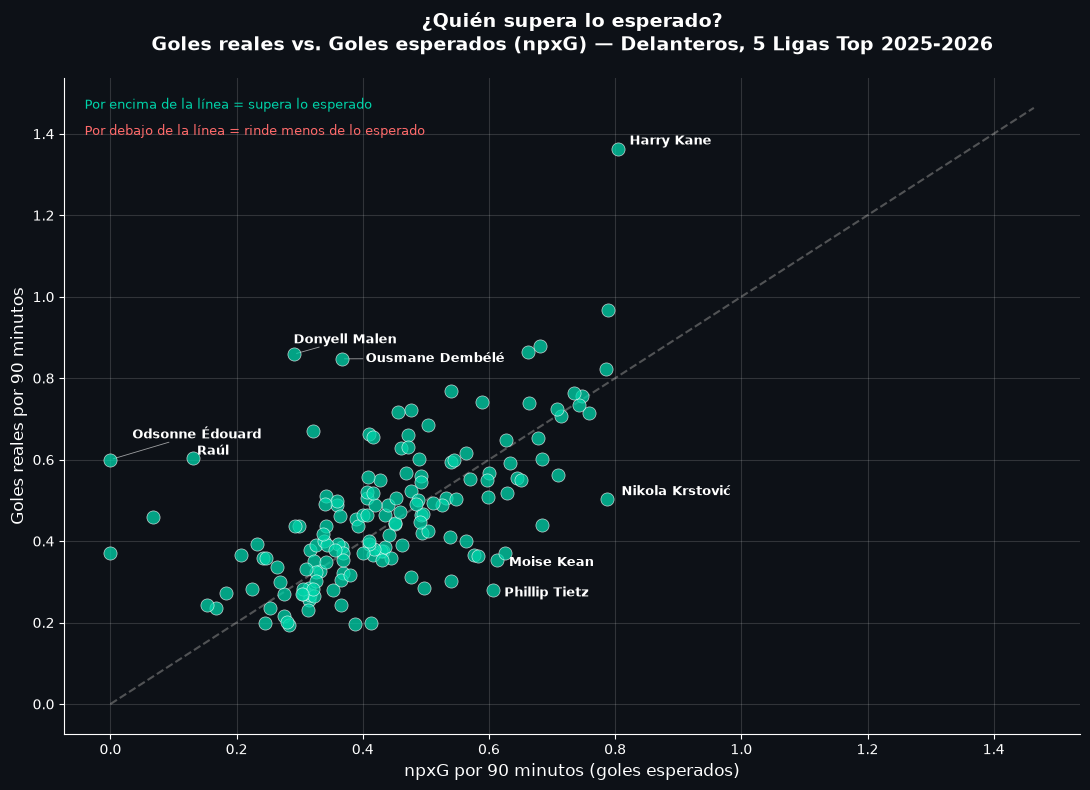

Guardado como grafico_linkedin.png


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

df = pd.read_csv("data_raw_fbref/dataset_con_kpis.csv")

delanteros = df[
    (df["Pos_Principal"] == "FW") &
    (df["KPI_npxG_90"].notna()) &
    (df["Performance_Gls"] >= 5)
].copy()

print(f"Delanteros incluidos en el gráfico: {len(delanteros)}")

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

ax.scatter(
    delanteros["KPI_npxG_90"], delanteros["KPI_Goles_90"],
    s=90, c="#00d4aa", alpha=0.75, edgecolors="white", linewidths=0.5, zorder=3
)

lim_max = max(delanteros["KPI_npxG_90"].max(), delanteros["KPI_Goles_90"].max()) + 0.1
ax.plot([0, lim_max], [0, lim_max], linestyle="--", color="gray", alpha=0.6, zorder=1)

delanteros["diferencia"] = delanteros["KPI_Goles_90"] - delanteros["KPI_npxG_90"]
destacados = pd.concat([
    delanteros.nlargest(5, "diferencia"),
    delanteros.nsmallest(3, "diferencia")
])

textos = []
for _, fila in destacados.iterrows():
    t = ax.text(
        fila["KPI_npxG_90"], fila["KPI_Goles_90"], fila["Player"],
        fontsize=9, color="white", weight="bold"
    )
    textos.append(t)

adjust_text(textos, ax=ax, arrowprops=dict(arrowstyle="-", color="white", lw=0.6, alpha=0.6))

ax.set_xlabel("npxG por 90 minutos (goles esperados)", fontsize=12, color="white")
ax.set_ylabel("Goles reales por 90 minutos", fontsize=12, color="white")
ax.set_title(
    "¿Quién supera lo esperado?\nGoles reales vs. Goles esperados (npxG) — Delanteros, 5 Ligas Top 2025-2026",
    fontsize=14, color="white", pad=20, weight="bold"
)

ax.text(0.02, 0.97, "Por encima de la línea = supera lo esperado",
        transform=ax.transAxes, fontsize=9, color="#00d4aa", va="top")
ax.text(0.02, 0.93, "Por debajo de la línea = rinde menos de lo esperado",
        transform=ax.transAxes, fontsize=9, color="#ff6b6b", va="top")

ax.grid(alpha=0.15)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafico_linkedin.png", dpi=200, facecolor=fig.get_facecolor())
plt.show()

print("Guardado como grafico_linkedin.png")

In [62]:
import pandas as pd

df = pd.read_csv("data_raw_fbref/dataset_con_kpis.csv")

top_goleadores = df.nlargest(20, "Performance_Gls")[
    ["Player", "Squad", "Pos", "Pos_Principal", "Performance_Gls", "npxG", "Playing Time_90s"]
]
print(top_goleadores.to_string(index=False))

            Player           Squad   Pos Pos_Principal  Performance_Gls      npxG  Playing Time_90s
        Harry Kane   Bayern Munich FW,MF            FW             36.0 21.244442              26.4
    Erling Haaland Manchester City    FW            FW             27.0 25.750661              32.8
     Kylian Mbappé     Real Madrid    FW            FW             25.0 19.107030              28.9
      Vedat Muriqi        Mallorca    FW            FW             23.0 16.427842              34.8
       Igor Thiago       Brentford    FW            FW             22.0 17.839253              36.5
    Esteban Lepaul          Rennes    FW            FW             20.0 12.694475              27.9
       Deniz Undav       Stuttgart FW,MF            FW             19.0 18.299771              24.9
      Ante Budimir         Osasuna    FW            FW             17.0 13.245544              32.6
   Serhou Guirassy        Dortmund    FW            FW             17.0 17.637852              26.0
